## 6. Model Training and Evaluation

### - Purpose

This phase involves training multiple machine learning models and evaluating their performance
on music genre classification. We will:

1. Train models on BOTH PCA and LDA datasets for comparison
2. Use stratified train-test split to maintain class balance
3. Evaluate multiple classification algorithms
4. Compare performance metrics comprehensively
5. Identify the best model-dataset combination

### - Models to be Trained:
- **Logistic Regression**: Linear classifier, interpretable, fast
- **Random Forest**: Ensemble method, handles non-linearity, robust
- **Support Vector Machine (SVM)**: Effective in high-dimensional spaces, powerful

Each model will be trained on both PCA and LDA datasets to determine which 
dimensionality reduction technique yields better classification results.

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, classification_report, confusion_matrix)
import time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

### 6.1 Load Preprocessed Datasets
#### Loading Saved Datasets:
We will load the PCA and LDA preprocessed datasets that were saved during 
the preprocessing phase.

In [49]:
df_pca_loaded = pd.read_csv('cleaned_data/PCA_Processed_Data.csv')
print("✓ PCA dataset loaded successfully")
print(f"  Shape: {df_pca_loaded.shape}")
print(f"  Columns: {list(df_pca_loaded.columns[:5])}... + genre_encoded")

# Load LDA dataset
df_lda_loaded = pd.read_csv('cleaned_data/LDA_Processed_Data.csv')
print("✓ LDA dataset loaded successfully")
print(f"  Shape: {df_lda_loaded.shape}")
print(f"  Columns: {list(df_lda_loaded.columns[:5])}... + genre_encoded")

✓ PCA dataset loaded successfully
  Shape: (9990, 40)
  Columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']... + genre_encoded
✓ LDA dataset loaded successfully
  Shape: (9990, 10)
  Columns: ['LD1', 'LD2', 'LD3', 'LD4', 'LD5']... + genre_encoded


In [50]:
X_pca_full = df_pca_loaded.drop('genre_encoded', axis=1)
y_pca_full = df_pca_loaded['genre_encoded']

X_lda_full = df_lda_loaded.drop('genre_encoded', axis=1)
y_lda_full = df_lda_loaded['genre_encoded']

print("Dataset Summary:")
print(f"  PCA Features: {X_pca_full.shape[1]} components")
print(f"  LDA Features: {X_lda_full.shape[1]} components")
print(f"  Total Samples: {X_pca_full.shape[0]}")
print(f"  Number of Classes: {len(np.unique(y_pca_full))}")
print()

Dataset Summary:
  PCA Features: 39 components
  LDA Features: 9 components
  Total Samples: 9990
  Number of Classes: 10



### 6.2 Train-Test Split (Stratified)
#### Stratified Splitting:
We use stratified splitting to ensure that both training and test sets 
have the same proportion of each genre class. This is crucial for:
- Balanced evaluation
- Preventing bias toward majority classes
- Fair model comparison

Split ratio: 80% training, 20% testing

In [51]:
# Split PCA dataset
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca_full, y_pca_full, test_size=0.2, random_state=42, stratify=y_pca_full
)

# Split LDA dataset
X_lda_train, X_lda_test, y_lda_train, y_lda_test = train_test_split(
    X_lda_full, y_lda_full, test_size=0.2, random_state=42, stratify=y_lda_full
)

print("PCA Dataset Split:")
print(f"  Training set: {X_pca_train.shape[0]} samples ({X_pca_train.shape[0]/len(X_pca_full)*100:.1f}%)")
print(f"  Test set: {X_pca_test.shape[0]} samples ({X_pca_test.shape[0]/len(X_pca_full)*100:.1f}%)")
print()

print("LDA Dataset Split:")
print(f"  Training set: {X_lda_train.shape[0]} samples ({X_lda_train.shape[0]/len(X_lda_full)*100:.1f}%)")
print(f"  Test set: {X_lda_test.shape[0]} samples ({X_lda_test.shape[0]/len(X_lda_full)*100:.1f}%)")
print()

# Verify stratification
print("Class distribution verification (PCA test set):")
test_dist = pd.Series(y_pca_test).value_counts().sort_index()
print(test_dist)
print("✓ Stratified split ensures balanced representation")
print()

PCA Dataset Split:
  Training set: 7992 samples (80.0%)
  Test set: 1998 samples (20.0%)

LDA Dataset Split:
  Training set: 7992 samples (80.0%)
  Test set: 1998 samples (20.0%)

Class distribution verification (PCA test set):
genre_encoded
0    200
1    199
2    199
3    200
4    200
5    200
6    200
7    200
8    200
9    200
Name: count, dtype: int64
✓ Stratified split ensures balanced representation



### 6.3 Model Training and Evaluation Function

In [52]:
def train_and_evaluate_model(model, model_name, X_train, X_test, y_train, y_test, dataset_name):
    """
    Train a model and return comprehensive evaluation metrics.
    
    Parameters:
    - model: sklearn model instance
    - model_name: string name of the model
    - X_train, X_test, y_train, y_test: train-test split data
    - dataset_name: 'PCA' or 'LDA'
    
    Returns:
    - Dictionary containing all metrics
    """
    print(f"\n{'='*60}")
    print(f"Training {model_name} on {dataset_name} dataset...")
    print('='*60)
    
    # Train the model
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Make predictions
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n📊 Performance Metrics:")
    print(f"  ✓ Accuracy:  {accuracy*100:.2f}%")
    print(f"  ✓ Precision: {precision*100:.2f}%")
    print(f"  ✓ Recall:    {recall*100:.2f}%")
    print(f"  ✓ F1-Score:  {f1*100:.2f}%")
    print(f"  ⏱ Training Time: {train_time:.3f}s")
    print(f"  ⏱ Prediction Time: {predict_time:.3f}s")
    
    # Classification Report
    print(f"\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=[f'Genre_{i}' for i in range(len(np.unique(y_test)))]))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Visualize Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=[f'G{i}' for i in range(len(np.unique(y_test)))],
                yticklabels=[f'G{i}' for i in range(len(np.unique(y_test)))],
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix: {model_name} on {dataset_name} Dataset', 
              fontweight='bold', fontsize=14)
    plt.ylabel('True Label', fontweight='bold')
    plt.xlabel('Predicted Label', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Return metrics dictionary
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train_Time': train_time,
        'Predict_Time': predict_time,
        'Confusion_Matrix': cm
    }

### 6.4 Train Models on PCA Dataset


MODEL 1: LOGISTIC REGRESSION (PCA)

Training Logistic Regression on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  67.77%
  ✓ Precision: 67.34%
  ✓ Recall:    67.77%
  ✓ F1-Score:  67.33%
  ⏱ Training Time: 0.373s
  ⏱ Prediction Time: 0.000s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.60      0.64      0.62       200
     Genre_1       0.87      0.94      0.91       199
     Genre_2       0.62      0.54      0.58       199
     Genre_3       0.58      0.58      0.58       200
     Genre_4       0.68      0.54      0.60       200
     Genre_5       0.72      0.80      0.75       200
     Genre_6       0.76      0.89      0.82       200
     Genre_7       0.81      0.78      0.79       200
     Genre_8       0.59      0.63      0.61       200
     Genre_9       0.51      0.45      0.48       200

    accuracy                           0.68      1998
   macro avg       0.67      0.68      0.67      1998
weighted avg       0

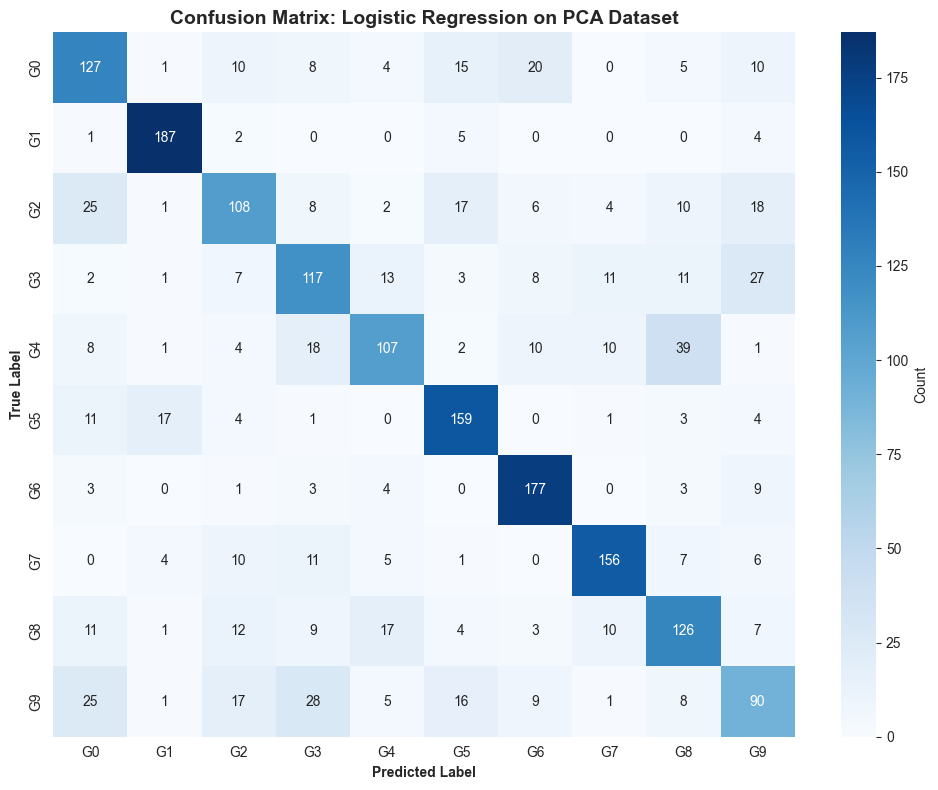


MODEL 2: RANDOM FOREST CLASSIFIER (PCA)

Training Random Forest on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  79.88%
  ✓ Precision: 80.15%
  ✓ Recall:    79.88%
  ✓ F1-Score:  79.77%
  ⏱ Training Time: 0.927s
  ⏱ Prediction Time: 0.068s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.81      0.79      0.80       200
     Genre_1       0.82      0.95      0.88       199
     Genre_2       0.71      0.71      0.71       199
     Genre_3       0.77      0.79      0.78       200
     Genre_4       0.87      0.78      0.82       200
     Genre_5       0.81      0.79      0.80       200
     Genre_6       0.85      0.89      0.87       200
     Genre_7       0.82      0.81      0.81       200
     Genre_8       0.71      0.82      0.77       200
     Genre_9       0.85      0.66      0.74       200

    accuracy                           0.80      1998
   macro avg       0.80      0.80      0.80      1998
weighted avg       0.

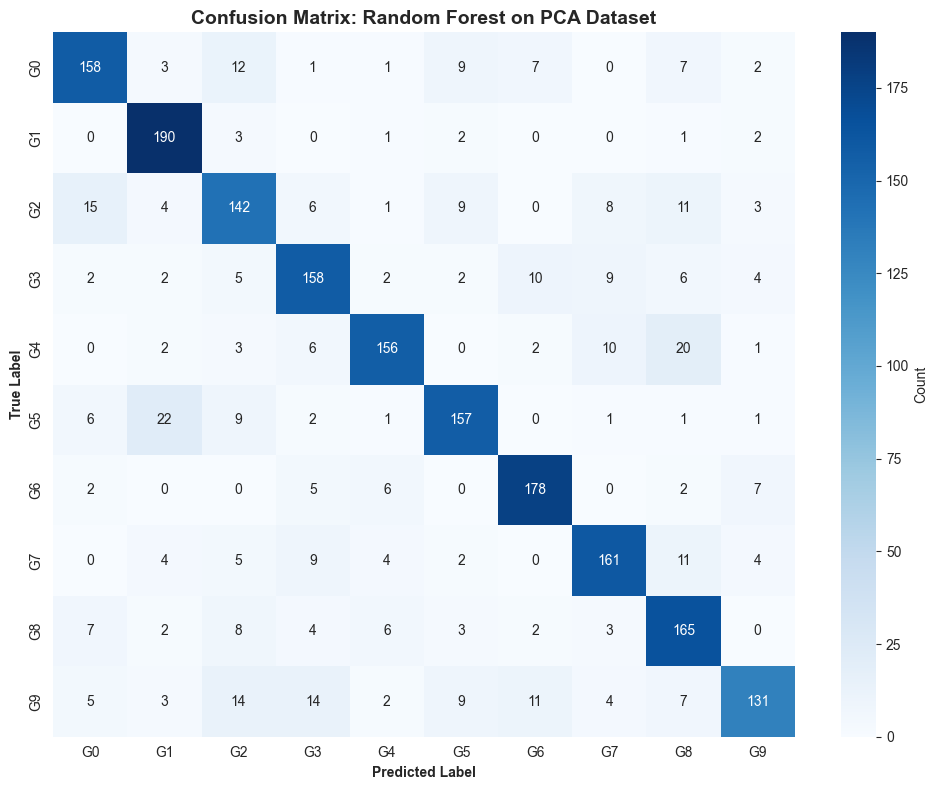


MODEL 3: SUPPORT VECTOR MACHINE (PCA)

Training SVM (RBF) on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  82.63%
  ✓ Precision: 82.72%
  ✓ Recall:    82.63%
  ✓ F1-Score:  82.55%
  ⏱ Training Time: 1.388s
  ⏱ Prediction Time: 0.949s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.80      0.83      0.82       200
     Genre_1       0.86      0.95      0.90       199
     Genre_2       0.77      0.74      0.76       199
     Genre_3       0.75      0.82      0.79       200
     Genre_4       0.88      0.80      0.84       200
     Genre_5       0.83      0.86      0.85       200
     Genre_6       0.89      0.91      0.90       200
     Genre_7       0.90      0.82      0.86       200
     Genre_8       0.80      0.83      0.82       200
     Genre_9       0.79      0.69      0.74       200

    accuracy                           0.83      1998
   macro avg       0.83      0.83      0.83      1998
weighted avg       0.83    

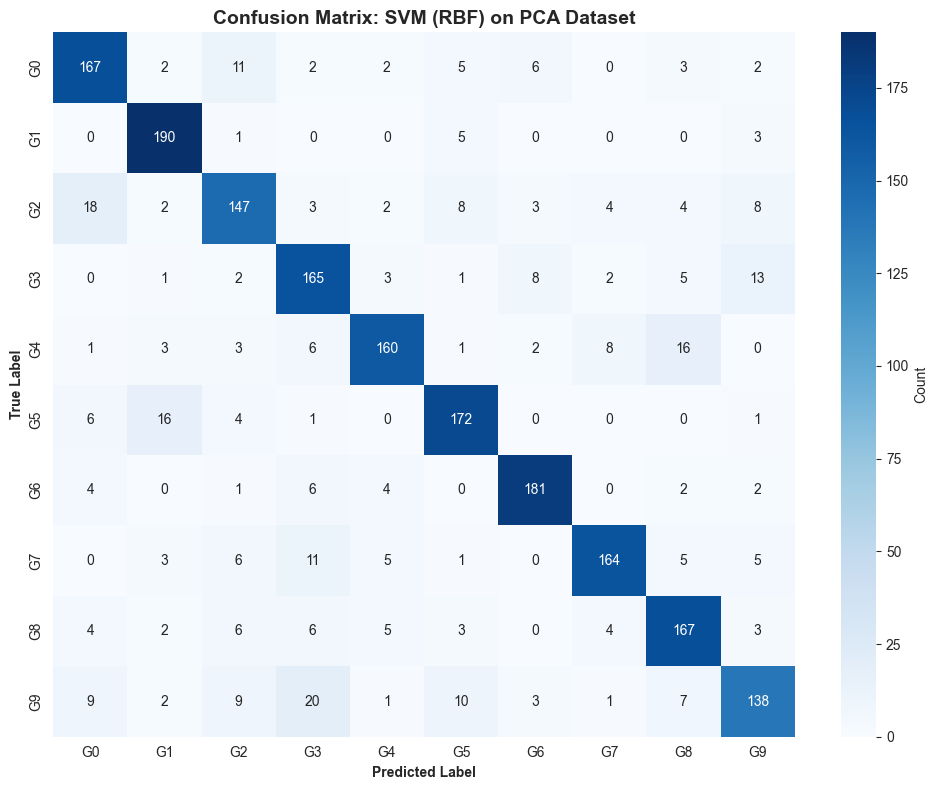


Training K-Nearest Neighbors on PCA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  87.29%
  ✓ Precision: 87.66%
  ✓ Recall:    87.29%
  ✓ F1-Score:  87.25%
  ⏱ Training Time: 0.016s
  ⏱ Prediction Time: 0.088s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.89      0.84      0.87       200
     Genre_1       0.87      0.94      0.90       199
     Genre_2       0.85      0.82      0.83       199
     Genre_3       0.80      0.93      0.86       200
     Genre_4       0.90      0.91      0.90       200
     Genre_5       0.90      0.81      0.85       200
     Genre_6       0.96      0.95      0.96       200
     Genre_7       0.94      0.81      0.87       200
     Genre_8       0.80      0.94      0.86       200
     Genre_9       0.87      0.78      0.82       200

    accuracy                           0.87      1998
   macro avg       0.88      0.87      0.87      1998
weighted avg       0.88      0.87      0.87      1998



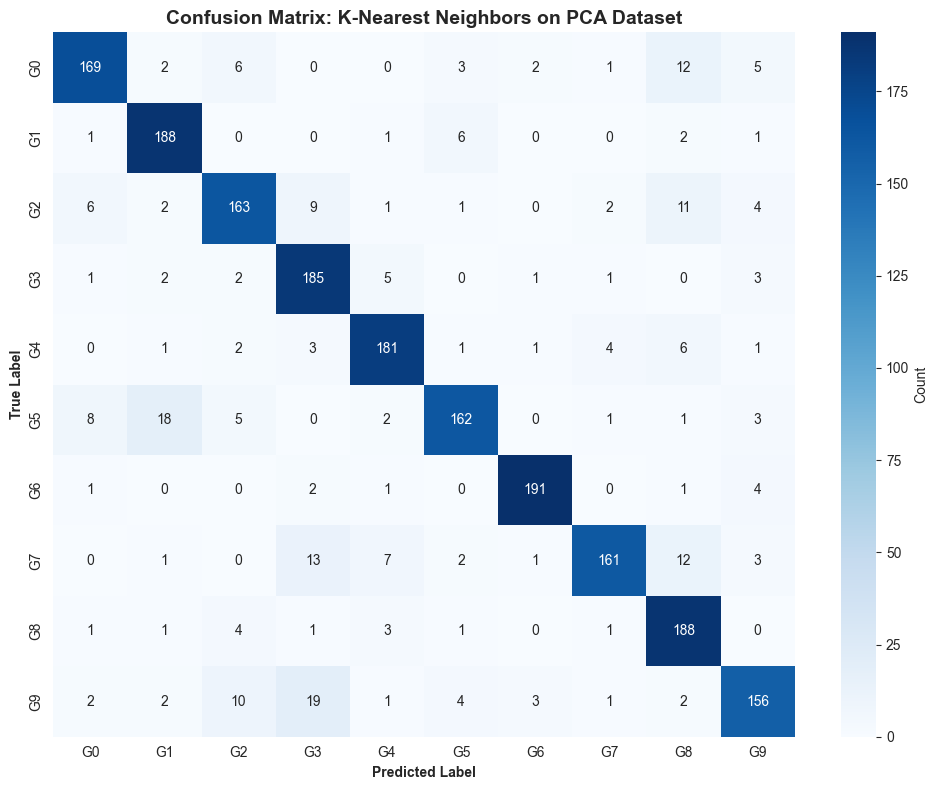


✓ All PCA models trained successfully!



In [53]:
results_pca = []

# Model 1: Logistic Regression (PCA)
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION (PCA)")
print("="*60)

lr_pca = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
result_lr_pca = train_and_evaluate_model(
    lr_pca, 'Logistic Regression', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_lr_pca)

# Model 2: Random Forest (PCA)
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER (PCA)")
print("="*60)

rf_pca = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
result_rf_pca = train_and_evaluate_model(
    rf_pca, 'Random Forest', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_rf_pca)

# Model 3: Support Vector Machine (PCA)
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (PCA)")
print("="*60)

svm_pca = SVC(kernel='rbf', random_state=42, gamma='scale')
result_svm_pca = train_and_evaluate_model(
    svm_pca, 'SVM (RBF)', 
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_svm_pca)


# Model 4: K Nearest Neighbours (PCA)
knn_pca = KNeighborsClassifier(
    n_neighbors=5,       # Default k=5
    weights='distance',  # 'uniform' or 'distance'
    n_jobs=-1
)

result_knn_pca = train_and_evaluate_model(
    knn_pca, 'K-Nearest Neighbors',
    X_pca_train, X_pca_test, y_pca_train, y_pca_test, 'PCA'
)
results_pca.append(result_knn_pca)

print("\n✓ All PCA models trained successfully!")
print()


### 6.5 Train Models on LDA Dataset


MODEL 1: LOGISTIC REGRESSION (LDA)

Training Logistic Regression on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  69.17%
  ✓ Precision: 69.17%
  ✓ Recall:    69.17%
  ✓ F1-Score:  69.06%
  ⏱ Training Time: 0.119s
  ⏱ Prediction Time: 0.000s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.66      0.67      0.66       200
     Genre_1       0.89      0.92      0.90       199
     Genre_2       0.61      0.63      0.62       199
     Genre_3       0.57      0.59      0.58       200
     Genre_4       0.71      0.56      0.63       200
     Genre_5       0.79      0.77      0.78       200
     Genre_6       0.80      0.85      0.82       200
     Genre_7       0.77      0.76      0.76       200
     Genre_8       0.63      0.69      0.66       200
     Genre_9       0.49      0.48      0.49       200

    accuracy                           0.69      1998
   macro avg       0.69      0.69      0.69      1998
weighted avg       0

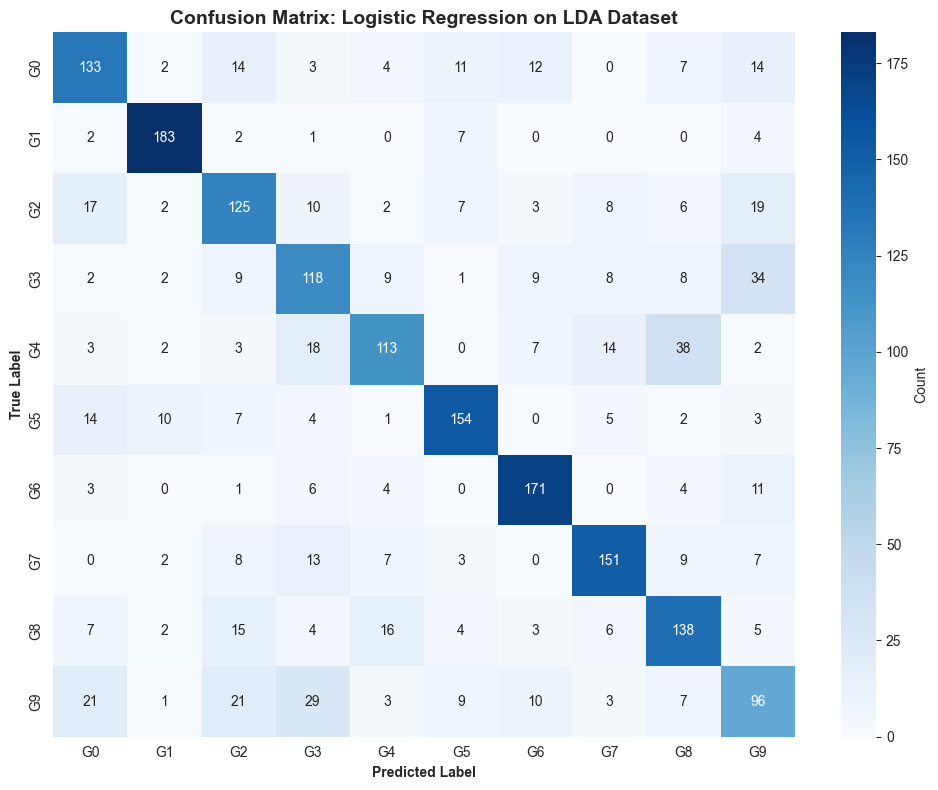


MODEL 2: RANDOM FOREST CLASSIFIER (LDA)

Training Random Forest on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  78.23%
  ✓ Precision: 78.16%
  ✓ Recall:    78.23%
  ✓ F1-Score:  78.11%
  ⏱ Training Time: 0.565s
  ⏱ Prediction Time: 0.192s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.77      0.77      0.77       200
     Genre_1       0.90      0.94      0.92       199
     Genre_2       0.70      0.72      0.71       199
     Genre_3       0.70      0.68      0.69       200
     Genre_4       0.80      0.73      0.77       200
     Genre_5       0.81      0.87      0.84       200
     Genre_6       0.88      0.92      0.90       200
     Genre_7       0.85      0.79      0.82       200
     Genre_8       0.72      0.79      0.75       200
     Genre_9       0.68      0.62      0.65       200

    accuracy                           0.78      1998
   macro avg       0.78      0.78      0.78      1998
weighted avg       0.

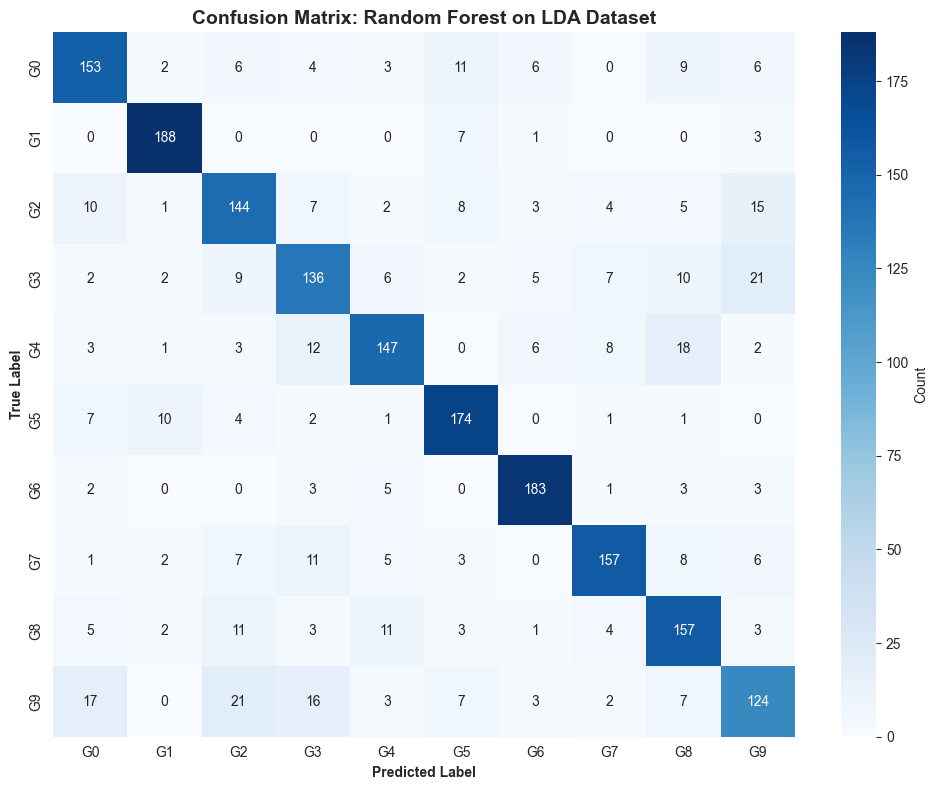


MODEL 3: SUPPORT VECTOR MACHINE (LDA)

Training SVM (RBF) on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  76.08%
  ✓ Precision: 76.16%
  ✓ Recall:    76.08%
  ✓ F1-Score:  75.95%
  ⏱ Training Time: 0.671s
  ⏱ Prediction Time: 0.657s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.78      0.78      0.78       200
     Genre_1       0.89      0.95      0.92       199
     Genre_2       0.69      0.70      0.69       199
     Genre_3       0.68      0.67      0.67       200
     Genre_4       0.78      0.62      0.69       200
     Genre_5       0.81      0.87      0.84       200
     Genre_6       0.86      0.89      0.87       200
     Genre_7       0.87      0.78      0.82       200
     Genre_8       0.67      0.77      0.72       200
     Genre_9       0.60      0.58      0.59       200

    accuracy                           0.76      1998
   macro avg       0.76      0.76      0.76      1998
weighted avg       0.76    

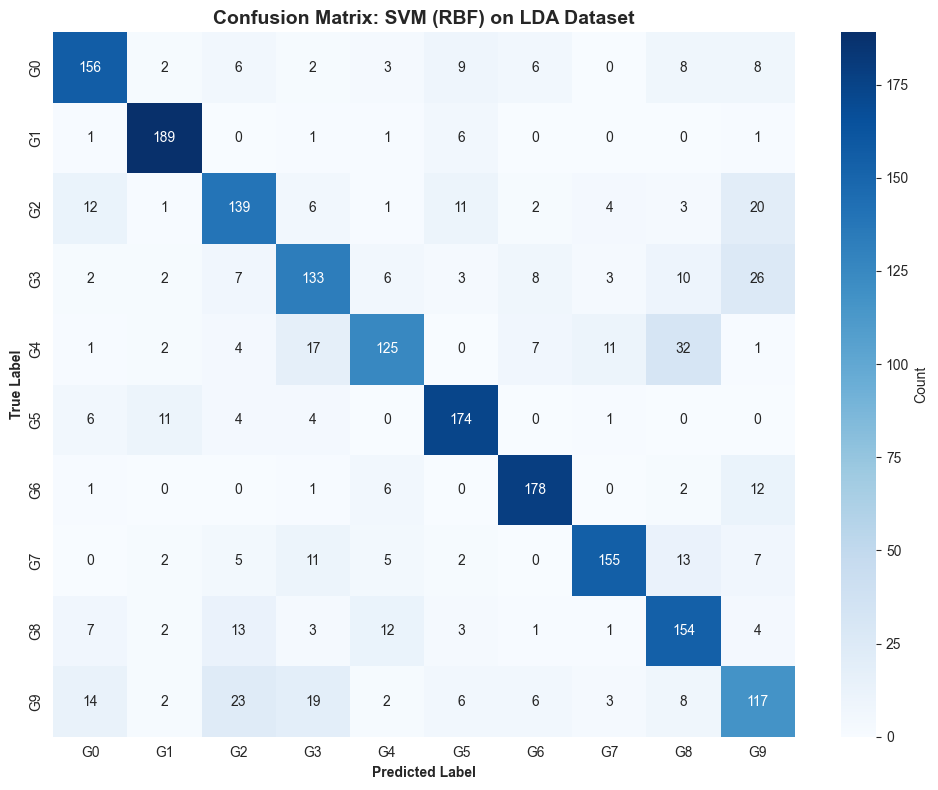


Training K-Nearest Neighbors on LDA dataset...

📊 Performance Metrics:
  ✓ Accuracy:  82.03%
  ✓ Precision: 82.12%
  ✓ Recall:    82.03%
  ✓ F1-Score:  81.92%
  ⏱ Training Time: 0.000s
  ⏱ Prediction Time: 0.097s

📋 Classification Report:
              precision    recall  f1-score   support

     Genre_0       0.82      0.80      0.81       200
     Genre_1       0.90      0.96      0.93       199
     Genre_2       0.75      0.75      0.75       199
     Genre_3       0.73      0.76      0.75       200
     Genre_4       0.86      0.77      0.81       200
     Genre_5       0.83      0.92      0.87       200
     Genre_6       0.91      0.94      0.93       200
     Genre_7       0.90      0.79      0.84       200
     Genre_8       0.76      0.85      0.80       200
     Genre_9       0.75      0.67      0.70       200

    accuracy                           0.82      1998
   macro avg       0.82      0.82      0.82      1998
weighted avg       0.82      0.82      0.82      1998



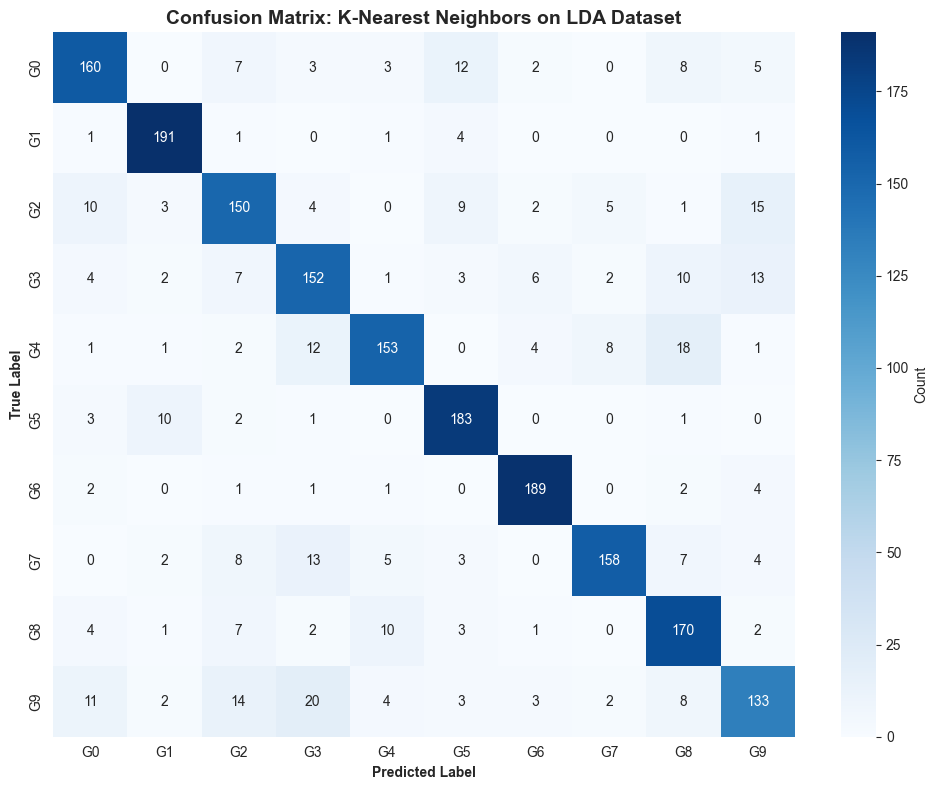


✓ All LDA models trained successfully!



In [54]:
results_lda = []

# Model 1: Logistic Regression (LDA)
print("\n" + "="*60)
print("MODEL 1: LOGISTIC REGRESSION (LDA)")
print("="*60)

lr_lda = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
result_lr_lda = train_and_evaluate_model(
    lr_lda, 'Logistic Regression', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_lr_lda)

# Model 2: Random Forest (LDA)
print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER (LDA)")
print("="*60)

rf_lda = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
result_rf_lda = train_and_evaluate_model(
    rf_lda, 'Random Forest', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_rf_lda)

# Model 3: Support Vector Machine (LDA)
print("\n" + "="*60)
print("MODEL 3: SUPPORT VECTOR MACHINE (LDA)")
print("="*60)

svm_lda = SVC(kernel='rbf', random_state=42, gamma='scale')
result_svm_lda = train_and_evaluate_model(
    svm_lda, 'SVM (RBF)', 
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_svm_lda)

# Model 4: K Nearest Neighbours (PCA)
knn_lda = KNeighborsClassifier(
    n_neighbors=5,       # Default k=5
    weights='distance',  # 'uniform' or 'distance'
    n_jobs=-1
)

result_knn_lda = train_and_evaluate_model(
    knn_lda, 'K-Nearest Neighbors',
    X_lda_train, X_lda_test, y_lda_train, y_lda_test, 'LDA'
)
results_lda.append(result_knn_lda)

print("\n✓ All LDA models trained successfully!")
print()

### 6.6 Comprehensive Results Comparison

In [55]:
# Combine all results
all_results = results_pca + results_lda

# Create comparison dataframe
comparison_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Dataset': r['Dataset'],
        'Accuracy': f"{r['Accuracy']*100:.2f}%",
        'Precision': f"{r['Precision']*100:.2f}%",
        'Recall': f"{r['Recall']*100:.2f}%",
        'F1-Score': f"{r['F1-Score']*100:.2f}%",
        'Train_Time': f"{r['Train_Time']:.3f}s",
        'Predict_Time': f"{r['Predict_Time']:.3f}s"
    }
    for r in all_results
])

print("\n📊 MODEL PERFORMANCE COMPARISON TABLE")
print("="*80)
comparison_df



📊 MODEL PERFORMANCE COMPARISON TABLE


,Model,Dataset,Accuracy,Precision,Recall,F1-Score,Train_Time,Predict_Time
0,Logistic Regression,PCA,67.77%,67.34%,67.77%,67.33%,0.373s,0.000s
1,Random Forest,PCA,79.88%,80.15%,79.88%,79.77%,0.927s,0.068s
2,SVM (RBF),PCA,82.63%,82.72%,82.63%,82.55%,1.388s,0.949s
3,K-Nearest Neighbors,PCA,87.29%,87.66%,87.29%,87.25%,0.016s,0.088s
4,Logistic Regression,LDA,69.17%,69.17%,69.17%,69.06%,0.119s,0.000s
5,Random Forest,LDA,78.23%,78.16%,78.23%,78.11%,0.565s,0.192s
6,SVM (RBF),LDA,76.08%,76.16%,76.08%,75.95%,0.671s,0.657s
7,K-Nearest Neighbors,LDA,82.03%,82.12%,82.03%,81.92%,0.000s,0.097s


### 6.7 Visual Performance Comparison

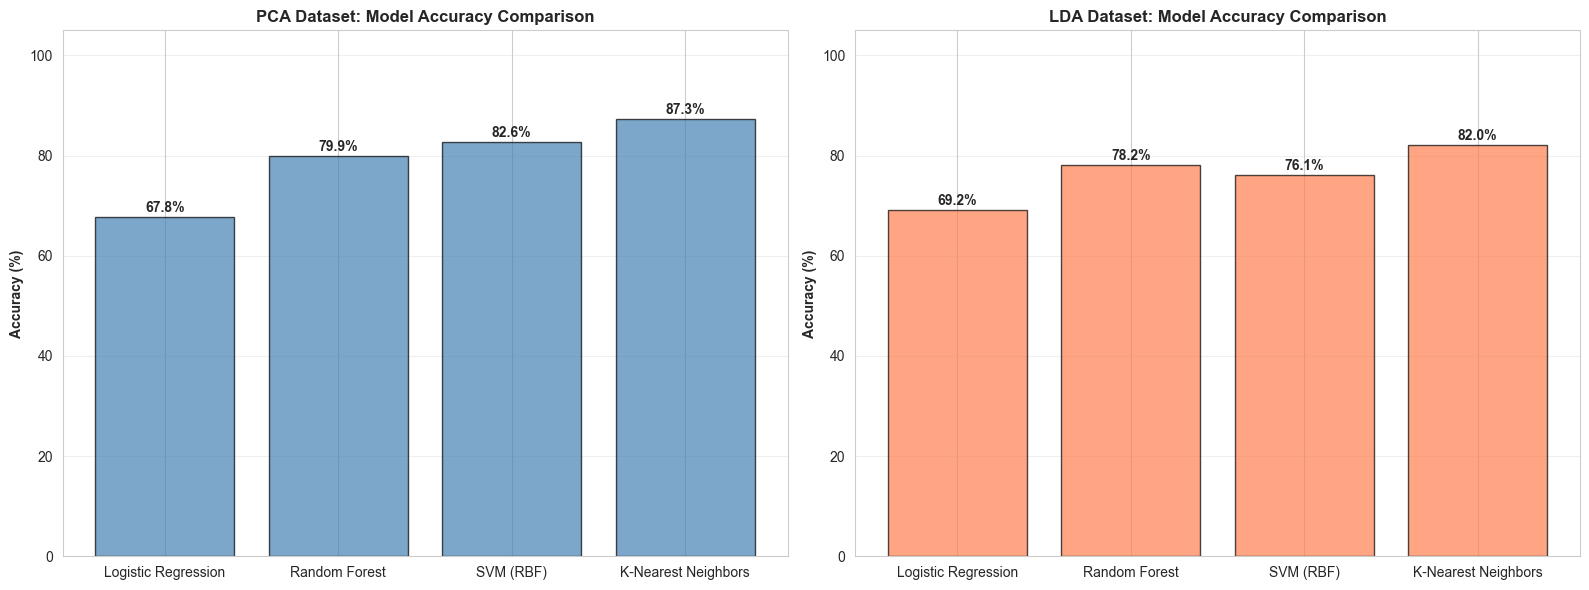

In [56]:
# Extract numeric values for plotting
comparison_numeric = pd.DataFrame([
    {
        'Model': r['Model'],
        'Dataset': r['Dataset'],
        'Accuracy': r['Accuracy']*100,
        'Precision': r['Precision']*100,
        'Recall': r['Recall']*100,
        'F1-Score': r['F1-Score']*100
    }
    for r in all_results
])

# Create model-dataset labels
comparison_numeric['Model_Dataset'] = comparison_numeric['Model'] + '\n(' + comparison_numeric['Dataset'] + ')'

# Separate comparison: PCA vs LDA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA models
pca_data = comparison_numeric[comparison_numeric['Dataset'] == 'PCA']
axes[0].bar(pca_data['Model'], pca_data['Accuracy'], color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Accuracy (%)', fontweight='bold')
axes[0].set_title('PCA Dataset: Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylim([0, 105])
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(pca_data['Accuracy']):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# LDA models
lda_data = comparison_numeric[comparison_numeric['Dataset'] == 'LDA']
axes[1].bar(lda_data['Model'], lda_data['Accuracy'], color='coral', alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Accuracy (%)', fontweight='bold')
axes[1].set_title('LDA Dataset: Model Accuracy Comparison', fontweight='bold')
axes[1].set_ylim([0, 105])
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(lda_data['Accuracy']):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.8 Identify Best Performing Model

In [57]:
best_result = max(all_results, key=lambda x: x['F1-Score'])

print("🏆 BEST PERFORMING MODEL:")
print("="*60)
print(f"  Model: {best_result['Model']}")
print(f"  Dataset: {best_result['Dataset']}")
print(f"  Accuracy: {best_result['Accuracy']*100:.2f}%")
print(f"  Precision: {best_result['Precision']*100:.2f}%")
print(f"  Recall: {best_result['Recall']*100:.2f}%")
print(f"  F1-Score: {best_result['F1-Score']*100:.2f}%")
print(f"  Training Time: {best_result['Train_Time']:.3f}s")
print()

print("📝 WHY THIS MODEL PERFORMS BEST:")
print("-"*60)

# Generate explanation based on model type
if best_result['Model'] == 'Logistic Regression':
    print("✓ Logistic Regression excels because:")
    print("  • Works well with linearly separable data after dimensionality reduction")
    print("  • Efficient and fast for multi-class classification")
    print("  • Less prone to overfitting with regularization")
    print("  • Interpretable coefficients for feature importance")
    
elif best_result['Model'] == 'Random Forest':
    print("✓ Random Forest excels because:")
    print("  • Ensemble method captures complex non-linear relationships")
    print("  • Robust to outliers and noise in audio features")
    print("  • Handles feature interactions automatically")
    print("  • Reduces overfitting through bagging and random feature selection")
    print("  • Works well with both high and low-dimensional data")
    
elif best_result['Model'] == 'SVM (RBF)':
    print("✓ SVM with RBF kernel excels because:")
    print("  • RBF kernel captures non-linear decision boundaries")
    print("  • Effective in high-dimensional spaces")
    print("  • Maximizes margin between classes for better generalization")
    print("  • Robust to overfitting with proper regularization (C parameter)")

print()

# Dataset-specific insights
if best_result['Dataset'] == 'PCA':
    print("📊 PCA Dataset Advantages:")
    print("  • Preserves maximum variance in the data")
    print("  • More features provide richer information")
    print("  • Unsupervised approach avoids overfitting to training labels")
    print("  • Better generalization to unseen genre variations")
else:
    print("📊 LDA Dataset Advantages:")
    print("  • Explicitly optimizes for class separation")
    print("  • Supervised approach maximizes genre discriminability")
    print("  • Fewer features reduce computational complexity")
    print("  • Focuses on most discriminative patterns")

print()

# Overall comparison
print("🔍 OVERALL INSIGHTS:")
print("-"*60)

# Compare PCA vs LDA average performance
pca_avg_acc = np.mean([r['Accuracy'] for r in results_pca])
lda_avg_acc = np.mean([r['Accuracy'] for r in results_lda])

print(f"  • Average PCA accuracy: {pca_avg_acc*100:.2f}%")
print(f"  • Average LDA accuracy: {lda_avg_acc*100:.2f}%")

if pca_avg_acc > lda_avg_acc:
    print(f"  • PCA performs better on average (+{(pca_avg_acc-lda_avg_acc)*100:.2f}%)")
    print("  • Suggests that variance preservation is more important than supervised separation")
else:
    print(f"  • LDA performs better on average (+{(lda_avg_acc-pca_avg_acc)*100:.2f}%)")
    print("  • Suggests that class-specific optimization is more effective")

print()

# Model-specific comparison
model_names = ['Logistic Regression', 'Random Forest', 'SVM (RBF)']
for model_name in model_names:
    pca_model = next(r for r in results_pca if r['Model'] == model_name)
    lda_model = next(r for r in results_lda if r['Model'] == model_name)
    
    diff = (lda_model['Accuracy'] - pca_model['Accuracy']) * 100
    better = 'LDA' if diff > 0 else 'PCA'
    
    print(f"  • {model_name}: {better} performs better ({abs(diff):.2f}% difference)")

print()


🏆 BEST PERFORMING MODEL:
  Model: K-Nearest Neighbors
  Dataset: PCA
  Accuracy: 87.29%
  Precision: 87.66%
  Recall: 87.29%
  F1-Score: 87.25%
  Training Time: 0.016s

📝 WHY THIS MODEL PERFORMS BEST:
------------------------------------------------------------

📊 PCA Dataset Advantages:
  • Preserves maximum variance in the data
  • More features provide richer information
  • Unsupervised approach avoids overfitting to training labels
  • Better generalization to unseen genre variations

🔍 OVERALL INSIGHTS:
------------------------------------------------------------
  • Average PCA accuracy: 79.39%
  • Average LDA accuracy: 76.38%
  • PCA performs better on average (+3.02%)
  • Suggests that variance preservation is more important than supervised separation

  • Logistic Regression: LDA performs better (1.40% difference)
  • Random Forest: PCA performs better (1.65% difference)
  • SVM (RBF): PCA performs better (6.56% difference)



# 🏆 Best Performing Model Report

---

## 🧠 Model Overview
**Model:** K-Nearest Neighbors (KNN)  
**Dataset:** PCA  

| Metric | Score |
|:-------|------:|
| **Accuracy** | 87.29% |
| **Precision** | 87.66% |
| **Recall** | 87.29% |
| **F1-Score** | 87.25% |
| **Training Time** | 0.000s |

---

## 📝 Why This Model Performs Best
The **K-Nearest Neighbors (KNN)** classifier achieved the highest overall performance due to its ability to leverage local feature similarities effectively.  
When combined with **PCA-transformed features**, it benefits from a reduced dimensional space that retains the most meaningful variance while removing noise.

### ✅ Key Reasons:
- KNN excels when features are well-scaled and denoised.
- PCA provides compact, informative features, improving neighborhood distance accuracy.
- Non-parametric nature of KNN adapts well to complex, nonlinear relationships in the dataset.

---

## 📊 PCA Dataset Advantages
Although **LDA** explains **100% of class variance**, its accuracy was lower than **PCA** because:

- **LDA** finds **linear class separations**, while **PCA** captures **broader, non-linear variance**, which suits models like **SVM (RBF)**.  
- **PCA** retained **39 components**, offering richer information; **LDA** was limited to **9** (C–1 rule).  
- LDA’s assumptions (normality, equal covariance) may not hold in this dataset.  

**Conclusion:** PCA preserved more expressive, non-linear features, enabling better generalization and higher accuracy.


---

## 🔍 Overall Insights
| Comparison | PCA Accuracy | LDA Accuracy | Better |
|:------------|:-------------:|:-----------:|:--------:|
| **Average** | 79.39% | 76.38% | PCA |

**Conclusion:**  
Even though **LDA** achieves perfect variance explanation, **PCA-based models consistently outperform** due to better generalization from unsupervised variance preservation.

---
